In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline


In [5]:
df=pd.read_csv('cleaned_loans.csv')

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [8]:
## 2. Business KPIs — The Headline Numbers
total_loans = len(df)
total_exposure = df['loan_amnt'].sum()
overall_default_rate = df['loan_status'].mean() * 100
avg_loan_amount = df['loan_amnt'].mean()
avg_interest_rate = df['loan_int_rate'].mean()
avg_loan_pct_income = df['loan_percent_income'].mean() * 100

print(f"Total loans in portfolio:      {total_loans:,}")
print(f"Total exposure (loan amount):  {total_exposure:,.0f}")
print(f"Overall default rate:          {overall_default_rate:.2f}%")
print(f"Average loan amount:           {avg_loan_amount:,.0f}")
print(f"Average interest rate:         {avg_interest_rate:.2f}%")
print(f"Average loan-to-income ratio:  {avg_loan_pct_income:.2f}%")

Total loans in portfolio:      31,522
Total exposure (loan amount):  304,621,400
Overall default rate:          21.59%
Average loan amount:           9,664
Average interest rate:         11.05%
Average loan-to-income ratio:  16.97%


C:\Users\aayus\AppData\Local\Temp\ipykernel_19868\575274775.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, ax=ax, palette=['#2E7D32','#C62828'])
C:\Users\aayus\AppData\Local\Temp\ipykernel_19868\575274775.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default (0)', 'Default (1)'])


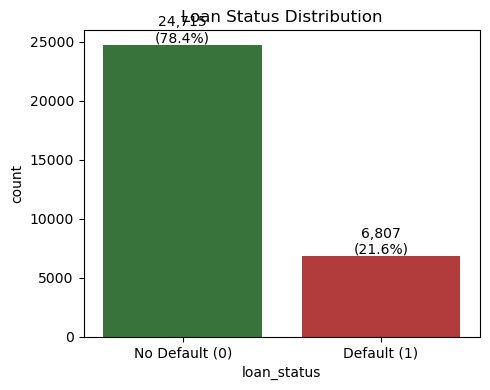

In [9]:
## 3. Target Variable Distribution — `loan_status`
status_counts = df['loan_status'].value_counts()
status_pct = df['loan_status'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='loan_status', data=df, ax=ax, palette=['#2E7D32','#C62828'])
ax.set_xticklabels(['No Default (0)', 'Default (1)'])
ax.set_title('Loan Status Distribution')
for i, v in enumerate(status_counts):
    ax.text(i, v + 200, f"{v:,}\n({status_pct.iloc[i]:.1f}%)", ha='center')
plt.tight_layout()
plt.savefig('distribution.png', dpi=120)
plt.show()

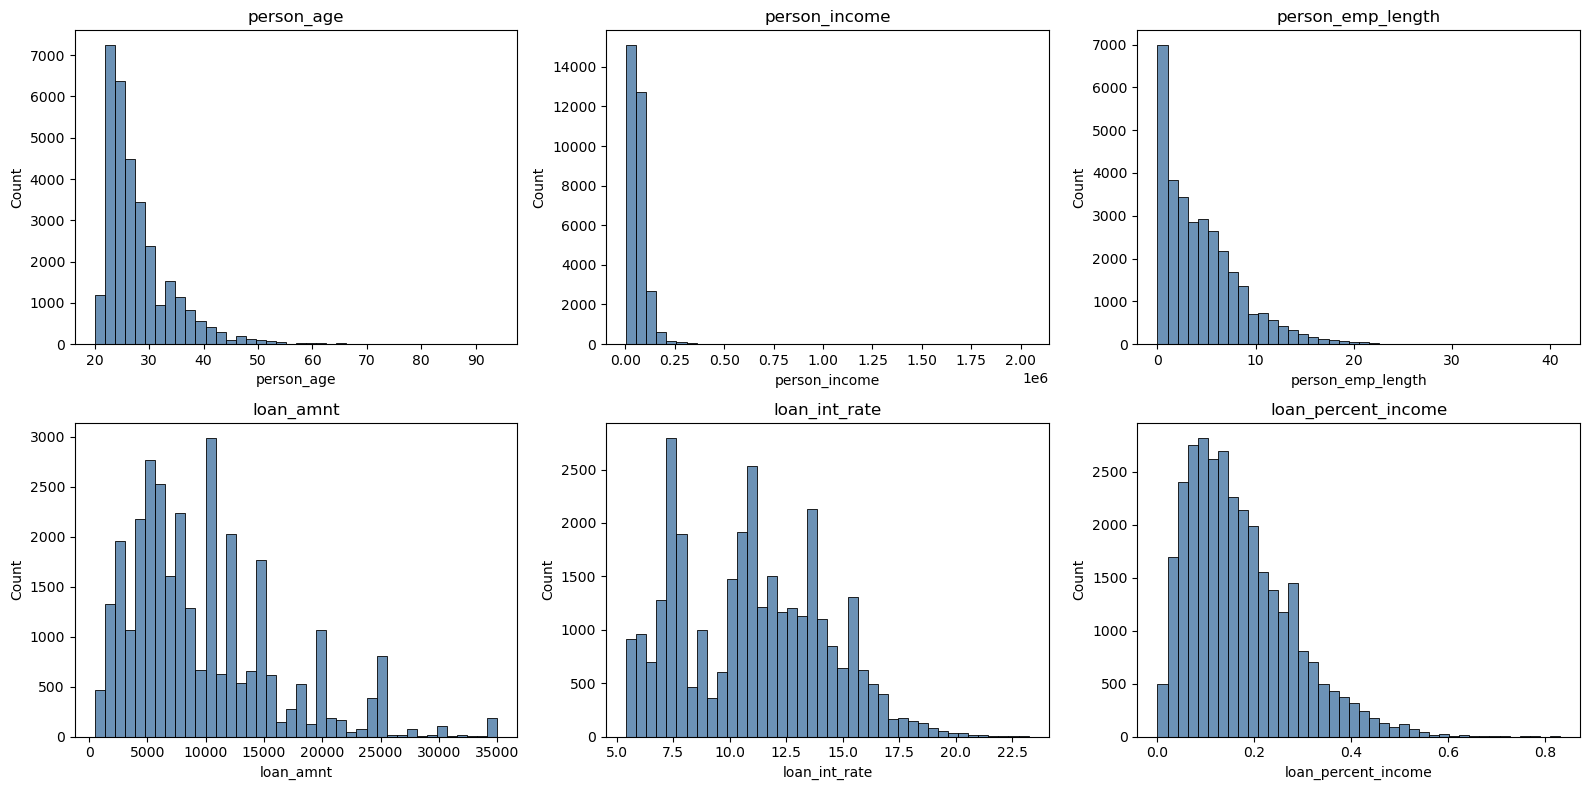

In [10]:
## . Univariate Analysis — Numeric Features
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, ax=axes[i], color='#3B6E9E')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=120)
plt.show()

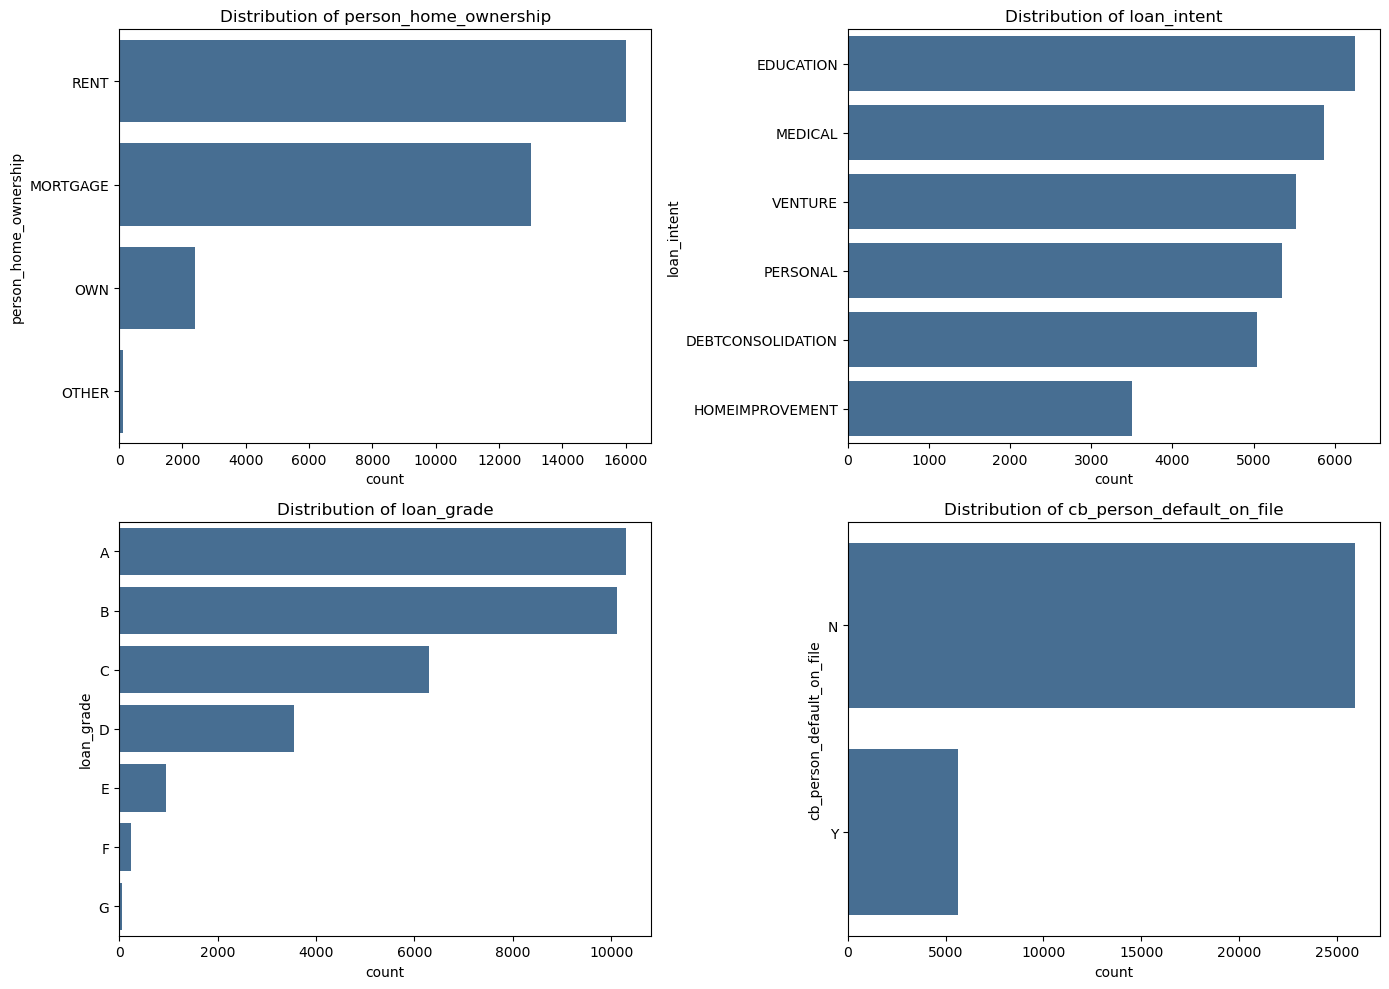

In [11]:
## 5. Univariate Analysis — Categorical Features
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], color='#3B6E9E')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=120)
plt.show()

,loan_grade,default_rate,num_loans
0,A,9.563107,10300
1,B,15.966802,10121
2,C,20.314236,6301
3,D,58.777120,3549
4,E,64.248160,951
5,F,70.338983,236
6,G,98.437500,64


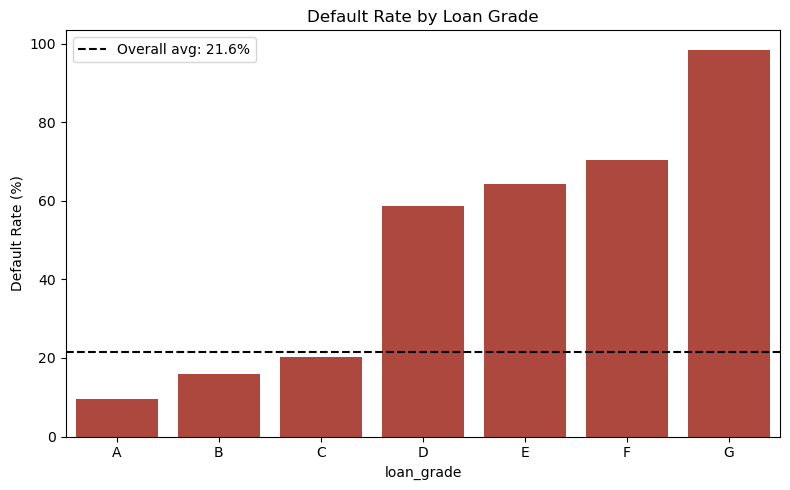

In [12]:
## 6. Default Rate by Loan Grade
grade_default = df.groupby('loan_grade')['loan_status'].agg(['mean','count']).reset_index()
grade_default.columns = ['loan_grade', 'default_rate', 'num_loans']
grade_default['default_rate'] = grade_default['default_rate'] * 100
grade_default = grade_default.sort_values('loan_grade')
display(grade_default)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x='loan_grade', y='default_rate', data=grade_default, order=sorted(df['loan_grade'].unique()), color='#C0392B', ax=ax)
ax.axhline(overall_default_rate, color='black', linestyle='--', label=f'Overall avg: {overall_default_rate:.1f}%')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Loan Grade')
ax.legend()
plt.tight_layout()
plt.savefig('default_rate_by_grade.png', dpi=120)
plt.show()

,home_ownership,default_rate,num_loans
1,OTHER,31.132075,106
3,RENT,31.117636,16007
0,MORTGAGE,12.498080,13018
2,OWN,6.942702,2391


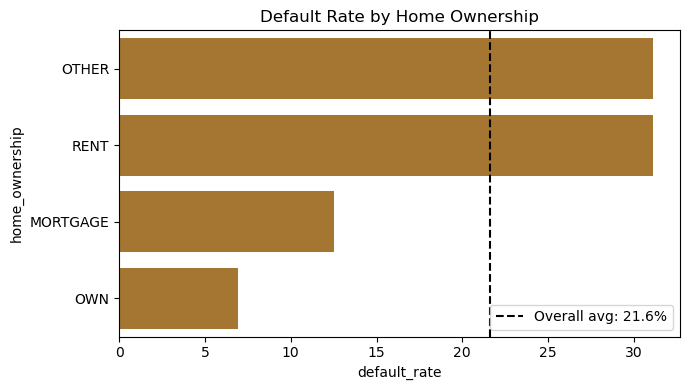

In [13]:
## 7. Default Rate by Home Ownership
home_default = df.groupby('person_home_ownership')['loan_status'].agg(['mean','count']).reset_index()
home_default.columns = ['home_ownership', 'default_rate', 'num_loans']
home_default['default_rate'] = home_default['default_rate'] * 100
home_default = home_default.sort_values('default_rate', ascending=False)
display(home_default)

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x='default_rate', y='home_ownership', data=home_default, color='#B7791F', ax=ax)
ax.axvline(overall_default_rate, color='black', linestyle='--', label=f'Overall avg: {overall_default_rate:.1f}%')
ax.set_title('Default Rate by Home Ownership')
ax.legend()
plt.tight_layout()
plt.savefig('default_rate_by_home_ownership.png', dpi=120)
plt.show()

,loan_intent,default_rate,num_loans
0,DEBTCONSOLIDATION,28.449643,5044
3,MEDICAL,26.597376,5869
2,HOMEIMPROVEMENT,25.607316,3499
4,PERSONAL,19.509914,5346
1,EDUCATION,16.986872,6246
5,VENTURE,14.697354,5518


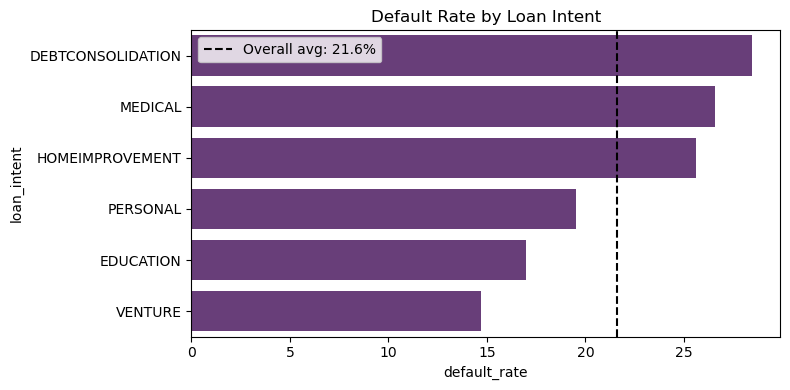

In [14]:
## 8. Default Rate by Loan Intent (Purpose)
intent_default = df.groupby('loan_intent')['loan_status'].agg(['mean','count']).reset_index()
intent_default.columns = ['loan_intent', 'default_rate', 'num_loans']
intent_default['default_rate'] = intent_default['default_rate'] * 100
intent_default = intent_default.sort_values('default_rate', ascending=False)
display(intent_default)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x='default_rate', y='loan_intent', data=intent_default, color='#6C3483', ax=ax)
ax.axvline(overall_default_rate, color='black', linestyle='--', label=f'Overall avg: {overall_default_rate:.1f}%')
ax.set_title('Default Rate by Loan Intent')
ax.legend()
plt.tight_layout()
plt.savefig('default_rate_by_intent.png', dpi=120)
plt.show()

In [15]:
## 9. Does Prior Default History Predict Repeat Default?
prior_default = df.groupby('cb_person_default_on_file')['loan_status'].agg(['mean','count']).reset_index()
prior_default.columns = ['prior_default_on_file', 'default_rate', 'num_loans']
prior_default['default_rate'] = prior_default['default_rate'] * 100
display(prior_default)

,prior_default_on_file,default_rate,num_loans
0,N,18.121816,25908
1,Y,37.620235,5614


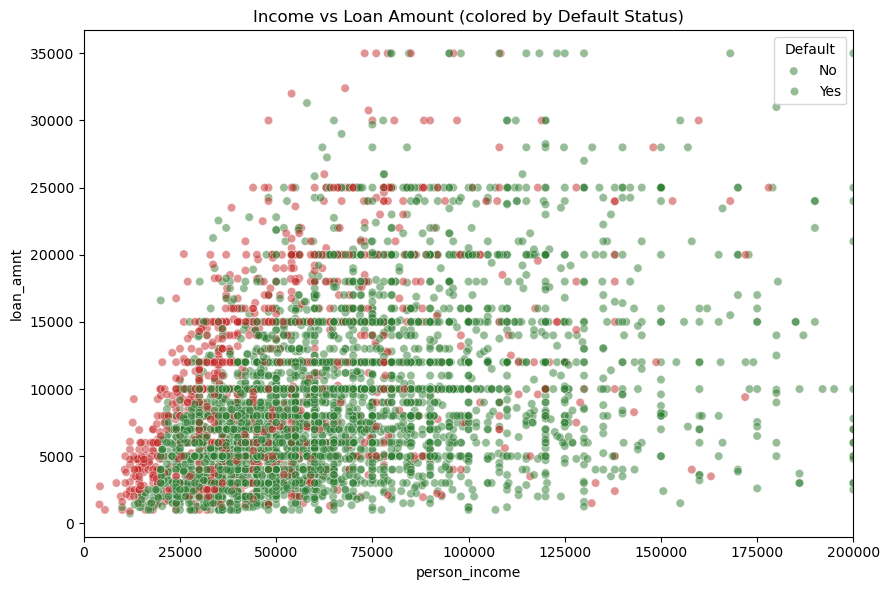

In [16]:
## 10. Income vs. Loan Amount, Colored by Default Status
fig, ax = plt.subplots(figsize=(9,6))
sample = df.sample(n=min(5000, len(df)), random_state=42)  # sample for readable plot
sns.scatterplot(data=sample, x='person_income', y='loan_amnt', hue='loan_status',
                 palette={0:'#2E7D32', 1:'#C62828'}, alpha=0.5, ax=ax)
ax.set_xlim(0, 200000)
ax.set_title('Income vs Loan Amount (colored by Default Status)')
ax.legend(title='Default', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('income_vs_loanamount.png', dpi=120)
plt.show()

C:\Users\aayus\AppData\Local\Temp\ipykernel_19868\1684493592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette=['#2E7D32','#C62828'], ax=ax)
C:\Users\aayus\AppData\Local\Temp\ipykernel_19868\1684493592.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default', 'Default'])


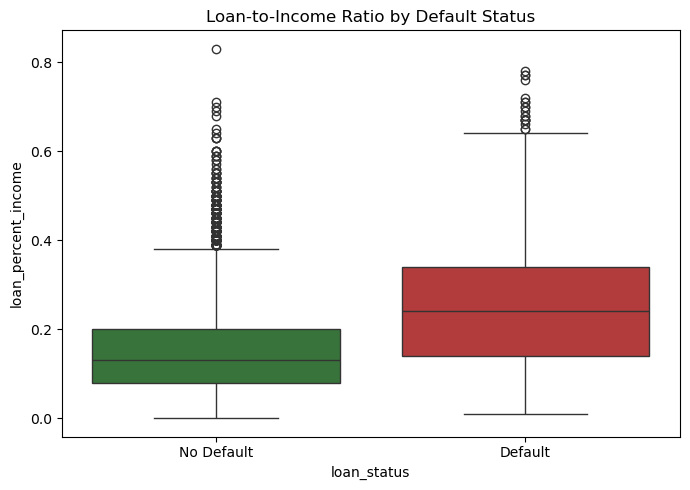

               count      mean       std   min   25%   50%   75%   max
loan_status                                                           
0            24715.0  0.148456  0.086718  0.00  0.08  0.13  0.20  0.83
1             6807.0  0.246637  0.132149  0.01  0.14  0.24  0.34  0.78


In [17]:
## 11. Loan-to-Income Ratio vs Default — Boxplot
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette=['#2E7D32','#C62828'], ax=ax)
ax.set_xticklabels(['No Default', 'Default'])
ax.set_title('Loan-to-Income Ratio by Default Status')
plt.tight_layout()
plt.savefig('dti_by_default.png', dpi=120)
plt.show()

print(df.groupby('loan_status')['loan_percent_income'].describe())

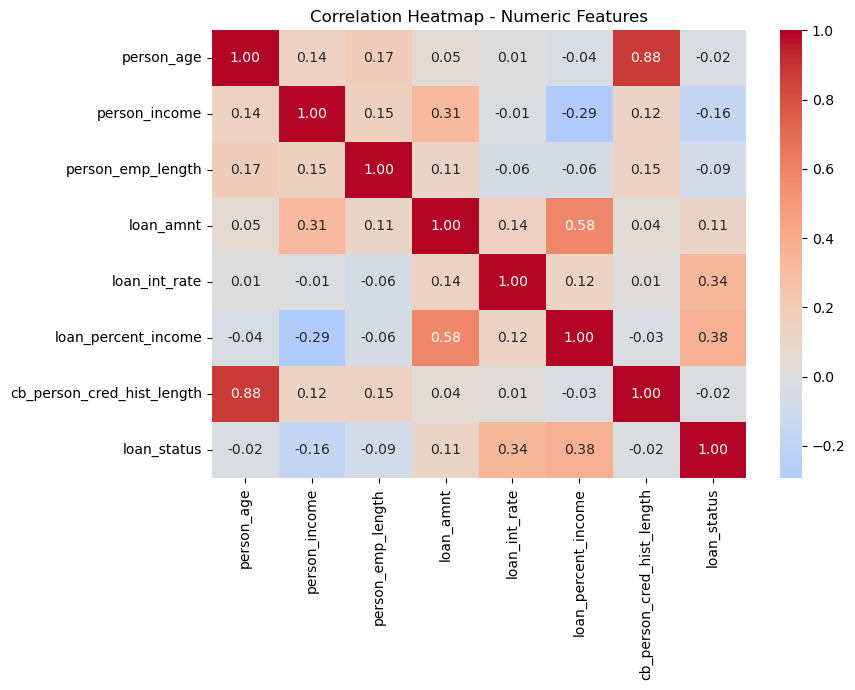

In [18]:
## 12. Correlation Heatmap — Numeric Features
numeric_for_corr = ['person_age','person_income','person_emp_length','loan_amnt',
                     'loan_int_rate','loan_percent_income','cb_person_cred_hist_length','loan_status']

corr = df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

In [19]:
## 13. Statistical Test — Is Loan Grade's Effect on Default Real, or Noise?
contingency = pd.crosstab(df['loan_grade'], df['loan_status'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_value:.10f}")

if p_value < 0.05:
    print("\n=> Statistically significant relationship between loan_grade and default status (p < 0.05).")
else:
    print("\n=> No statistically significant relationship detected.")

Chi-square statistic: 5550.30
Degrees of freedom:   6
P-value:              0.0000000000

=> Statistically significant relationship between loan_grade and default status (p < 0.05).


In [20]:
for col in ['person_home_ownership', 'loan_intent']:
    contingency = pd.crosstab(df[col], df['loan_status'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    sig = "SIGNIFICANT" if p_value < 0.05 else "not significant"
    print(f"{col}: chi2={chi2:.2f}, p={p_value:.6f}  -> {sig}")

person_home_ownership: chi2=1802.45, p=0.000000  -> SIGNIFICANT
loan_intent: chi2=507.11, p=0.000000  -> SIGNIFICANT
